<a href="https://colab.research.google.com/github/Nabeel-Aly/IPPR-lab_work/blob/main/day_2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
def intensity_transformations(img):
  img= img.astype(np.float64)
  L=256 #gray levels

  #1.Image Negative
  negative=L-1-img

  #2. Log transformation: s=c*log(1+r)
  c=(L-1)/(np.log(1+np.max(img)))
  log_img=c*np.log(1+img)

  #3. Power-Law(Gamma)Transformation: s=c*r^gamma
  gamma=0.5 #<1 brightens,>1 darkens
  c=1.0
  gamma_img = c*np.power(img/255.0,gamma)*255

  #4. Contrast Streching: linear strech to [0,255]
  r_min, r_max = img.min(), img.max()
  contrast=(img- r_min)/(r_max-r_min)*255

  images=[
      img.astype(np.uint8),
      negative.astype(np.uint8),
      log_img.astype(np.uint8),
      gamma_img.astype(np.uint8),
      contrast.astype(np.uint8)
  ]
  titles=['Original','Negative','Log Transform',f'Gamma(Y=(gamma))','Contrast Strech']
  show(images,titles,figsize=(20,4))
  print("intensity transformation complete.")
  intensity_transformations(img)

Saving IMG20260523082354.jpg to IMG20260523082354.jpg


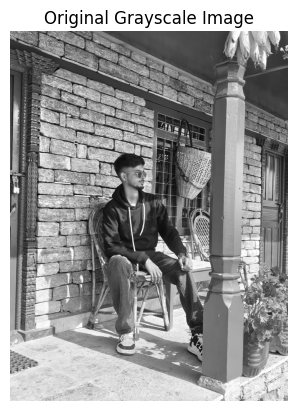

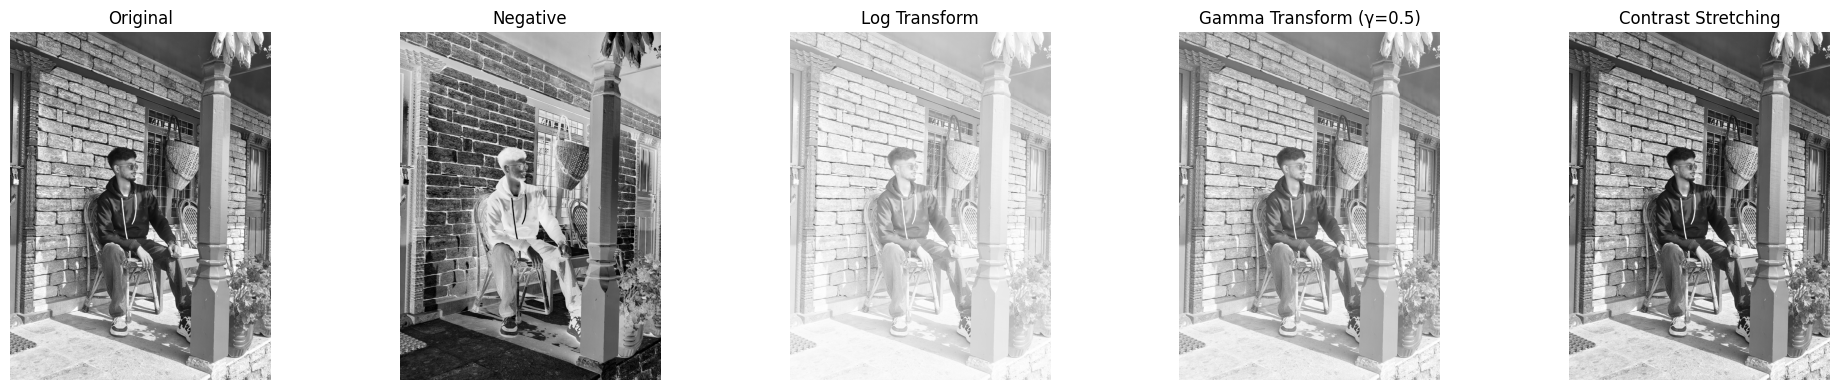

Intensity transformation complete.


In [9]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 2. UPLOAD IMAGE
# =========================
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Show original grayscale image
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()


# =========================
# 3. SHOW FUNCTION
# =========================
def show(images, titles, figsize=(20,4)):
    plt.figure(figsize=figsize)

    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# =========================
# 4. INTENSITY TRANSFORMATIONS
# =========================
def intensity_transformations(img):

    img = img.astype(np.float64)
    L = 256  # gray levels

    # 1. Image Negative
    negative = L - 1 - img

    # 2. Log Transformation
    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    # 3. Gamma Transformation
    gamma = 0.5
    gamma_img = np.power(img / 255.0, gamma) * 255

    # 4. Contrast Stretching
    r_min, r_max = img.min(), img.max()
    contrast = (img - r_min) / (r_max - r_min) * 255

    # Convert to uint8
    images = [
        img.astype(np.uint8),
        negative.astype(np.uint8),
        log_img.astype(np.uint8),
        gamma_img.astype(np.uint8),
        contrast.astype(np.uint8)
    ]

    titles = [
        "Original",
        "Negative",
        "Log Transform",
        "Gamma Transform (γ=0.5)",
        "Contrast Stretching"
    ]

    show(images, titles)
    print("Intensity transformation complete.")


# =========================
# 5. FUNCTION CALL
# =========================
intensity_transformations(img_gray)